In [1]:
import pandas as pd
import numpy as np 

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from xgboost import XGBRegressor
import pickle


In [2]:
df=pd.read_csv("demand_forecasting.csv")
df.head(3)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157


In [3]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [4]:
features=[
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [5]:
target="Demand"

In [6]:
X=df[features].copy()
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [7]:
y=df[target]


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [9]:
label_encoders={}
categorical_cols=X.select_dtypes(include="object").columns

In [10]:
categorical_cols

Index(['Category'], dtype='object')

In [11]:
for col in categorical_cols:
    le=LabelEncoder()
    X[col]=le.fit_transform(X[col])
    label_encoders[col]=le
    

In [12]:
label_encoders

{'Category': LabelEncoder()}

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)


In [14]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,1
1,80.16,15,117,1,92.02,0
2,62.94,10,247,1,60.08,0
3,87.63,10,139,0,85.19,1
4,54.41,0,152,0,51.63,3
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,4
75996,42.92,5,137,0,40.73,4
75997,17.81,10,197,0,19.41,0
75998,151.72,0,125,0,143.71,2


In [15]:
xgb=XGBRegressor(objective="reg:squarederror",n_jobs=-1)


In [16]:
param_dict={
    "n_estimators":[200,300,500],
    "max_depth":[3,4,6,8],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.7,0.8,1.0],
    "colsample_bytree":[0.7,0.8,1.0],
    "min_child_weight":[1,3,5]
}

In [17]:
random_search=RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dict,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [18]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

In [19]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 500,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.01,
 'colsample_bytree': 1.0}

In [20]:
best_model =random_search.best_estimator_

In [21]:
y_pred=best_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

35.654440617434844


In [26]:
best_model.feature_importances_

array([0.04761768, 0.01169584, 0.0111815 , 0.71133626, 0.01298943,
       0.20517933], dtype=float32)

In [28]:
feature_importance=pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [29]:
feature_importance

Promotion             0.711336
Category              0.205179
Price                 0.047618
Competitor Pricing    0.012989
Discount              0.011696
Inventory Level       0.011181
dtype: float32

<Axes: title={'center': 'Feature Importances'}>

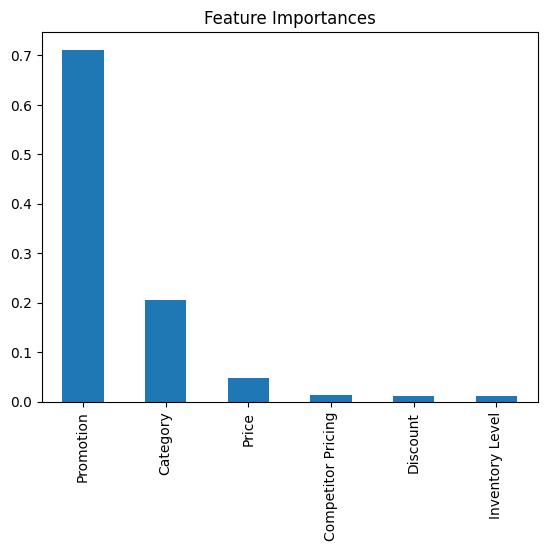

In [30]:
feature_importance.plot(kind="bar",title="Feature Importances")

In [31]:
with open("label_encoders.pkl","wb")as f:
    pickle.dump(label_encoders,f)

In [32]:
with open("xgboost_demand_model.pkl","wb") as f:
    pickle.dump(best_model,f)